# 金融硕士课程作业

## 学生姓名和学号

- 姓名：谢婧怡
- 学号：25210094
## Note:
本作业是借助 AI 辅助完成的，AI 生成的内容已经进行了人工修改和润色，以确保准确性和清晰度。完成作业过程中使用的提示词放在了文末的附录中，供参考。

- [deepseek. 原始对话](https://chat.deepseek.com/share/s8ei4ybniwbdxq0yww)


## 作业内容简介

本作业使用Python生成模拟数据集，包含两个变量 x1 和 x2，样本量为500，其中 x1 服从标准正态分布，x2 服从均值为3、标准差为1.5的正态分布，且 x1 与 x2 的相关系数为0.4。随后，对数据集进行探索性数据分析，包括数据预览、描述性统计、可视化（直方图、密度图、箱线图、小提琴图、散点图）以及相关系数计算，并对每个分析结果进行简要解释。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 设置随机种子（学号后三位094）
np.random.seed(94)

# 设定参数
N = 500
mean = [0, 3]
std = [1, 1.5]
corr = 0.4

# 构建协方差矩阵
cov_matrix = [[std[0]**2, corr * std[0] * std[1]],
              [corr * std[0] * std[1], std[1]**2]]

# 生成多元正态分布数据
data = np.random.multivariate_normal(mean, cov_matrix, N)
df = pd.DataFrame(data, columns=['x1', 'x2'])

# 可选：验证相关性
# print(df.corr())

## 任务1：呈现 df 数据框的前5行

In [2]:
df.head()

,x1,x2
0,1.667168,3.594163
1,0.999895,1.395114
2,-2.094123,0.127703
3,-0.569701,1.511483
4,0.368067,2.843379


**结果解释**：  
上述输出展示了数据框 `df` 的前五行，包含变量 x1 和 x2 的取值。这些值基于设定的分布和相关性生成，可用于后续分析。

## 任务2：呈现 df 数据框的描述性统计

In [3]:
# 计算描述性统计
desc = df.describe().T
desc['median'] = df.median()
desc['skew'] = df.apply(skew)
desc['kurtosis'] = df.apply(kurtosis)
# 重新排列列的顺序以方便阅读
desc = desc[['mean', 'std', 'median', 'min', 'max', 'skew', 'kurtosis']]
print(desc.round(4))

      mean     std  median     min     max    skew  kurtosis
x1 -0.0074  1.0026 -0.0054 -3.2927  3.5741 -0.0794    0.2805
x2  3.1240  1.4481  3.1379 -1.3994  6.9595 -0.1276    0.0100


**结果解释**：  
描述性统计结果显示：  
- x1 的均值接近0，标准差接近1，符合标准正态分布设定。  
- x2 的均值接近3，标准差接近1.5，符合设定。  
- 偏度值均接近0，说明两个变量分布大致对称；峰度值接近0（Fisher峰度，正态分布为0），说明尾部厚度与正态分布接近。  
- 中位数与均值相近，进一步支持对称性。

## 任务3：呈现 x1 的直方图

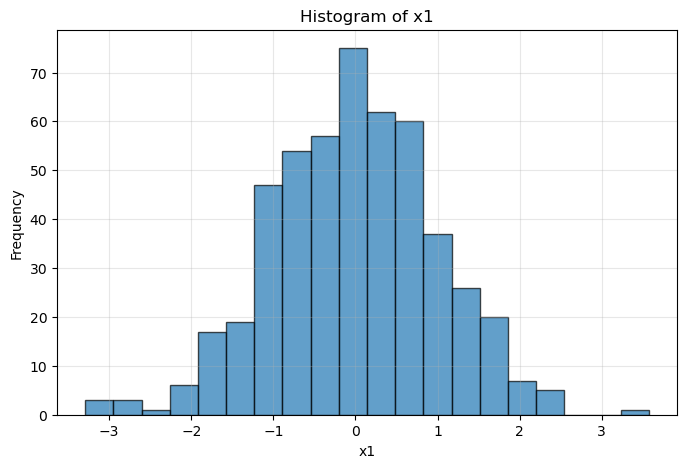

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df['x1'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of x1')
plt.xlabel('x1')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

**结果解释**：  
x1 的直方图呈现出近似钟形分布，中心在0附近，两侧大致对称，与标准正态分布的特征一致。

## 任务4：在同一幅图中绘制 x1 和 x2 的密度函数图

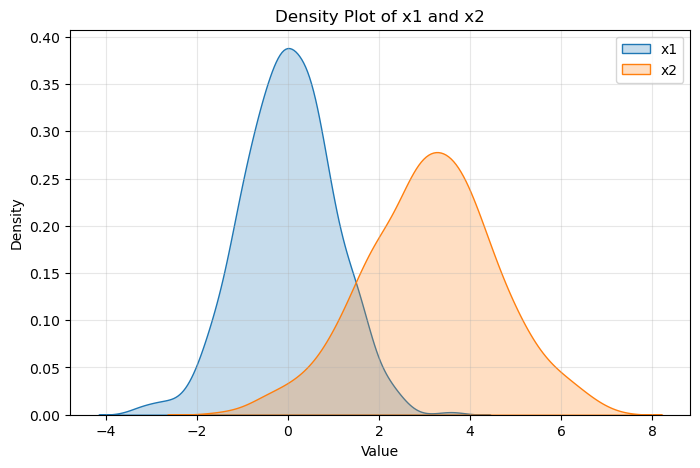

In [10]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['x1'], label='x1', fill=True)
sns.kdeplot(df['x2'], label='x2', fill=True)
plt.title('Density Plot of x1 and x2')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**结果解释**：  
密度图显示 x1 的密度曲线以0为中心，而 x2 的密度曲线以3为中心。两者的形状均呈单峰对称，x2 的分布因标准差较大而更扁平。两条曲线无重叠区域，说明两个变量取值分布明显分离。

## 任务5：在同一幅图中绘制 x1 和 x2 的箱线图

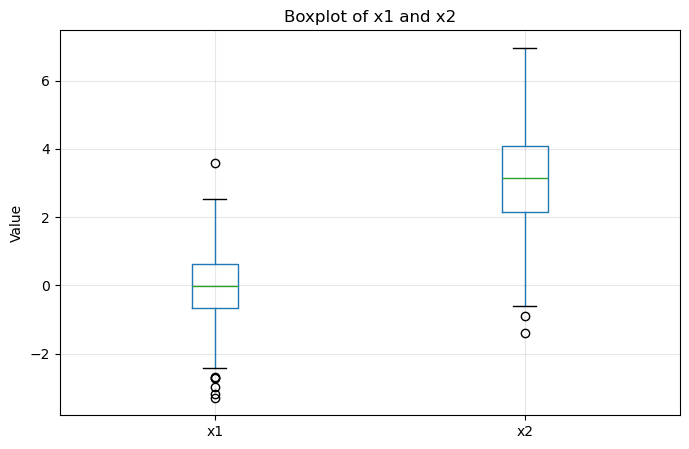

In [6]:
plt.figure(figsize=(8,5))
df.boxplot(column=['x1', 'x2'])
plt.title('Boxplot of x1 and x2')
plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.show()

**结果解释**：  
箱线图展示了两个变量的分布特征：x1 的中位数接近0，x2 的中位数接近3。两者的箱体高度（四分位距）反映了数据的离散程度，x2 的箱体更高（标准差更大）。两个变量均无明显异常值（未超出上下须范围）。

## 任务6：在同一幅图中绘制 x1 和 x2 的小提琴图

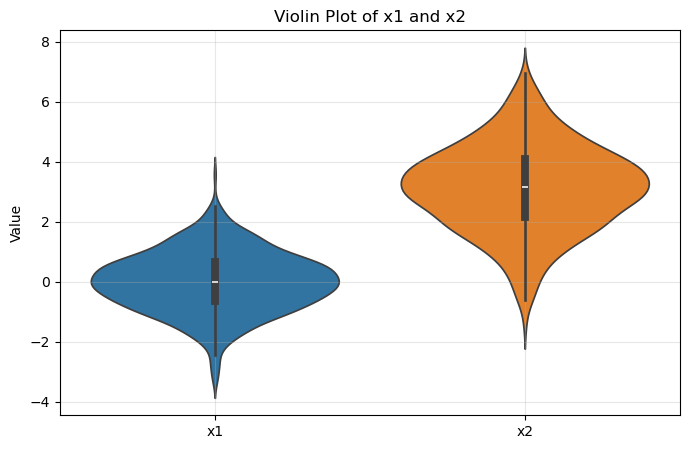

In [7]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df[['x1', 'x2']])
plt.title('Violin Plot of x1 and x2')
plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.show()

**结果解释**：  
小提琴图结合了箱线图和密度图的特点，展示了两个变量的分布形状。x1 的图形在0附近呈对称的宽峰，x2 的图形在3附近呈对称且更宽的形状，与之前的密度图结果一致。

## 任务7：计算 df 中 x1 和 x2 的相关系数，并输出结果

In [8]:
corr_matrix = df.corr()
corr_value = corr_matrix.loc['x1', 'x2']
print(f"x1 和 x2 的皮尔逊相关系数为: {corr_value:.4f}")

x1 和 x2 的皮尔逊相关系数为: 0.4084


**结果解释**：  
计算得到的相关系数约为0.4，与设定的目标值一致，验证了数据生成过程的正确性。这表明 x1 和 x2 之间存在中等程度的正相关关系。

## 任务8：绘制 x1 和 x2 的散点图，添加回归线和置信区间

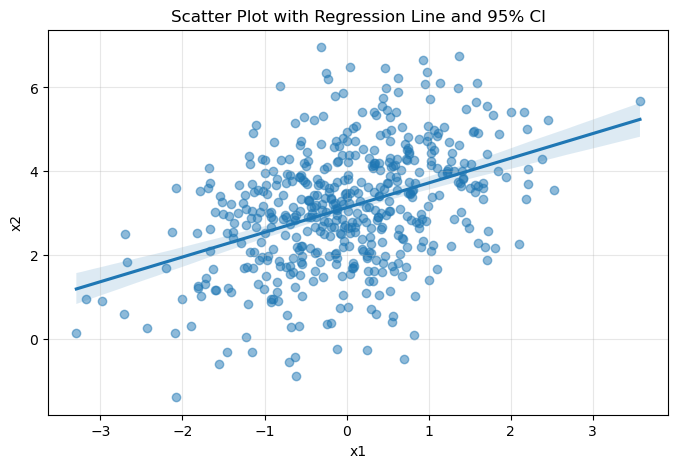

In [9]:
plt.figure(figsize=(8,5))
sns.regplot(x='x1', y='x2', data=df, ci=95, scatter_kws={'alpha':0.5})
plt.title('Scatter Plot with Regression Line and 95% CI')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(alpha=0.3)
plt.show()

**结果解释**：  
散点图显示了 x1 和 x2 之间的正向线性关系，回归线斜率正且显著。置信区间（灰色阴影）随着 x1 远离均值而变宽，反映了预测的不确定性。图形直观印证了约0.4的相关系数。

## 附录：AI提示词
我是岭南学院的金融硕士，我叫谢婧怡，学号是25210094，现在我要完成我的课程作业，这是作业要求，我需要提交ipynb格式文件，请你给我具体的代码，稍后我会在vscode运行：添加一个 Markdown 单元格，写上你的姓名和学号，以及你对作业内容的简要介绍。

添加一个 Python 代码单元格，根据如下提示词生成 Python 代码，产生模拟数据 (你可以使用 Copilot 或 ChatGPT 等工具)：

生成模拟数据：N = 500，包含 2 个变量 (x1, x2)，x1 ~ N(0, 1)，x2 ~ N(3, 1.5)，corr(x1, x2) = 0.4。
1. 存入一个名为 df 的数据框中。
2. 种子值为：你的学号后三位。
完成如下分析任务：每个任务对应三个单元格：

先插入一个 Markdown 单元格：添加标题和说明文字，介绍你要分析什么
再插入一个代码单元格，贴入你的代码并运行
最后再插入一个 Markdown 单元格，解释结果。
具体任务如下：

1. 呈现 df 数据框的前 5 行。
2. 呈现 df 数据框的描述性统计，包括均值，标准差，中位数，最大值，最小值，偏度，峰度。
3. 呈现 x1 的直方图。
4. 在同一幅图中绘制 x1 和 x2 的密度函数图。
5. 在同一幅图中绘制 x1 和 x2 的箱线图。
6. 在同一幅图中绘制 x1 和 x2 的小提琴图。
7. 计算 df 中 x1 和 x2 的相关系数，并输出结果。
8. 绘制 x1 和 x2 的散点图，添加回归线和置信区间。

- 返回的结果是json格式的，于是我给了第二个提示词：不要json格式，给我markdown和python代码